In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.9 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

print("YOLOv8 nano model loaded successfully!")
print(model)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 nano model loaded successfully!
YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=

In [ ]:
%pip install gdown

In [ ]:
file_id = '1Uba6CHJRCvF-rgfCXDR6NhTnOvngWsfe'
!gdown --id {file_id} -O dataset.zip

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1Uba6CHJRCvF-rgfCXDR6NhTnOvngWsfe
From (redirected): https://drive.google.com/uc?id=1Uba6CHJRCvF-rgfCXDR6NhTnOvngWsfe&confirm=t&uuid=7d8210e9-7572-4775-ae15-e70c512e5fc8
To: /content/dataset.zip
100% 4.90G/4.90G [01:19<00:00, 61.3MB/s]


In [ ]:
import zipfile
import os

with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

print("Dataset extracted to 'dataset/' directory.")

!ls -R dataset

Streaming output truncated to the last 5000 lines.
collapsed_building_image0034_1.txt  flood_image0029_1.txt
collapsed_building_image0034_2.txt  flood_image0029_3.txt
collapsed_building_image0034_3.txt  flood_image0029_4.txt
collapsed_building_image0035_2.txt  flood_image0030_0.txt
collapsed_building_image0035_4.txt  flood_image0030_1.txt
collapsed_building_image0036_0.txt  flood_image0030_2.txt
collapsed_building_image0036_2.txt  flood_image0030_3.txt
collapsed_building_image0036_3.txt  flood_image0031_0.txt
collapsed_building_image0036_4.txt  flood_image0031_4.txt
collapsed_building_image0037_0.txt  flood_image0032_0.txt
collapsed_building_image0037_1.txt  flood_image0032_3.txt
collapsed_building_image0038_0.txt  flood_image0033_0.txt
collapsed_building_image0038_1.txt  flood_image0033_1.txt
collapsed_building_image0038_2.txt  flood_image0033_3.txt
collapsed_building_image0038_3.txt  flood_image0033_4.txt
collapsed_building_image0038_4.txt  flood_image0034_2.txt
collapsed_building_im

In [ ]:
import os

dataset_path = 'dataset/new_dataset3'

print(f"Checking for training data at: {os.path.join(dataset_path, 'train/images')}")
print(f"Checking for validation data at: {os.path.join(dataset_path, 'val/images')}")
print(f"Checking for testing data at: {os.path.join(dataset_path, 'test/images')}")

Checking for training data at: dataset/new_dataset3/train/images
Checking for validation data at: dataset/new_dataset3/val/images
Checking for testing data at: dataset/new_dataset3/test/images


In [ ]:
yaml_content = f"""
train: {dataset_path}/train/images
val: {dataset_path}/val/images
test: {dataset_path}/test/images

nc: 4
names: ['collapsed_building', 'fire', 'flood', 'traffic_incident']
"""

with open('data.yaml', 'w') as f:
    f.write(yaml_content)

print("data.yaml created successfully:")
!cat data.yaml

data.yaml created successfully:

train: dataset/new_dataset3/train/images
val: dataset/new_dataset3/val/images
test: dataset/new_dataset3/test/images

nc: 4
names: ['collapsed_building', 'fire', 'flood', 'traffic_incident']


In [ ]:
results = model.train(data='data.yaml', epochs=10, imgsz=640)

print("Model training complete!")

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, pl

Displaying training results plot:


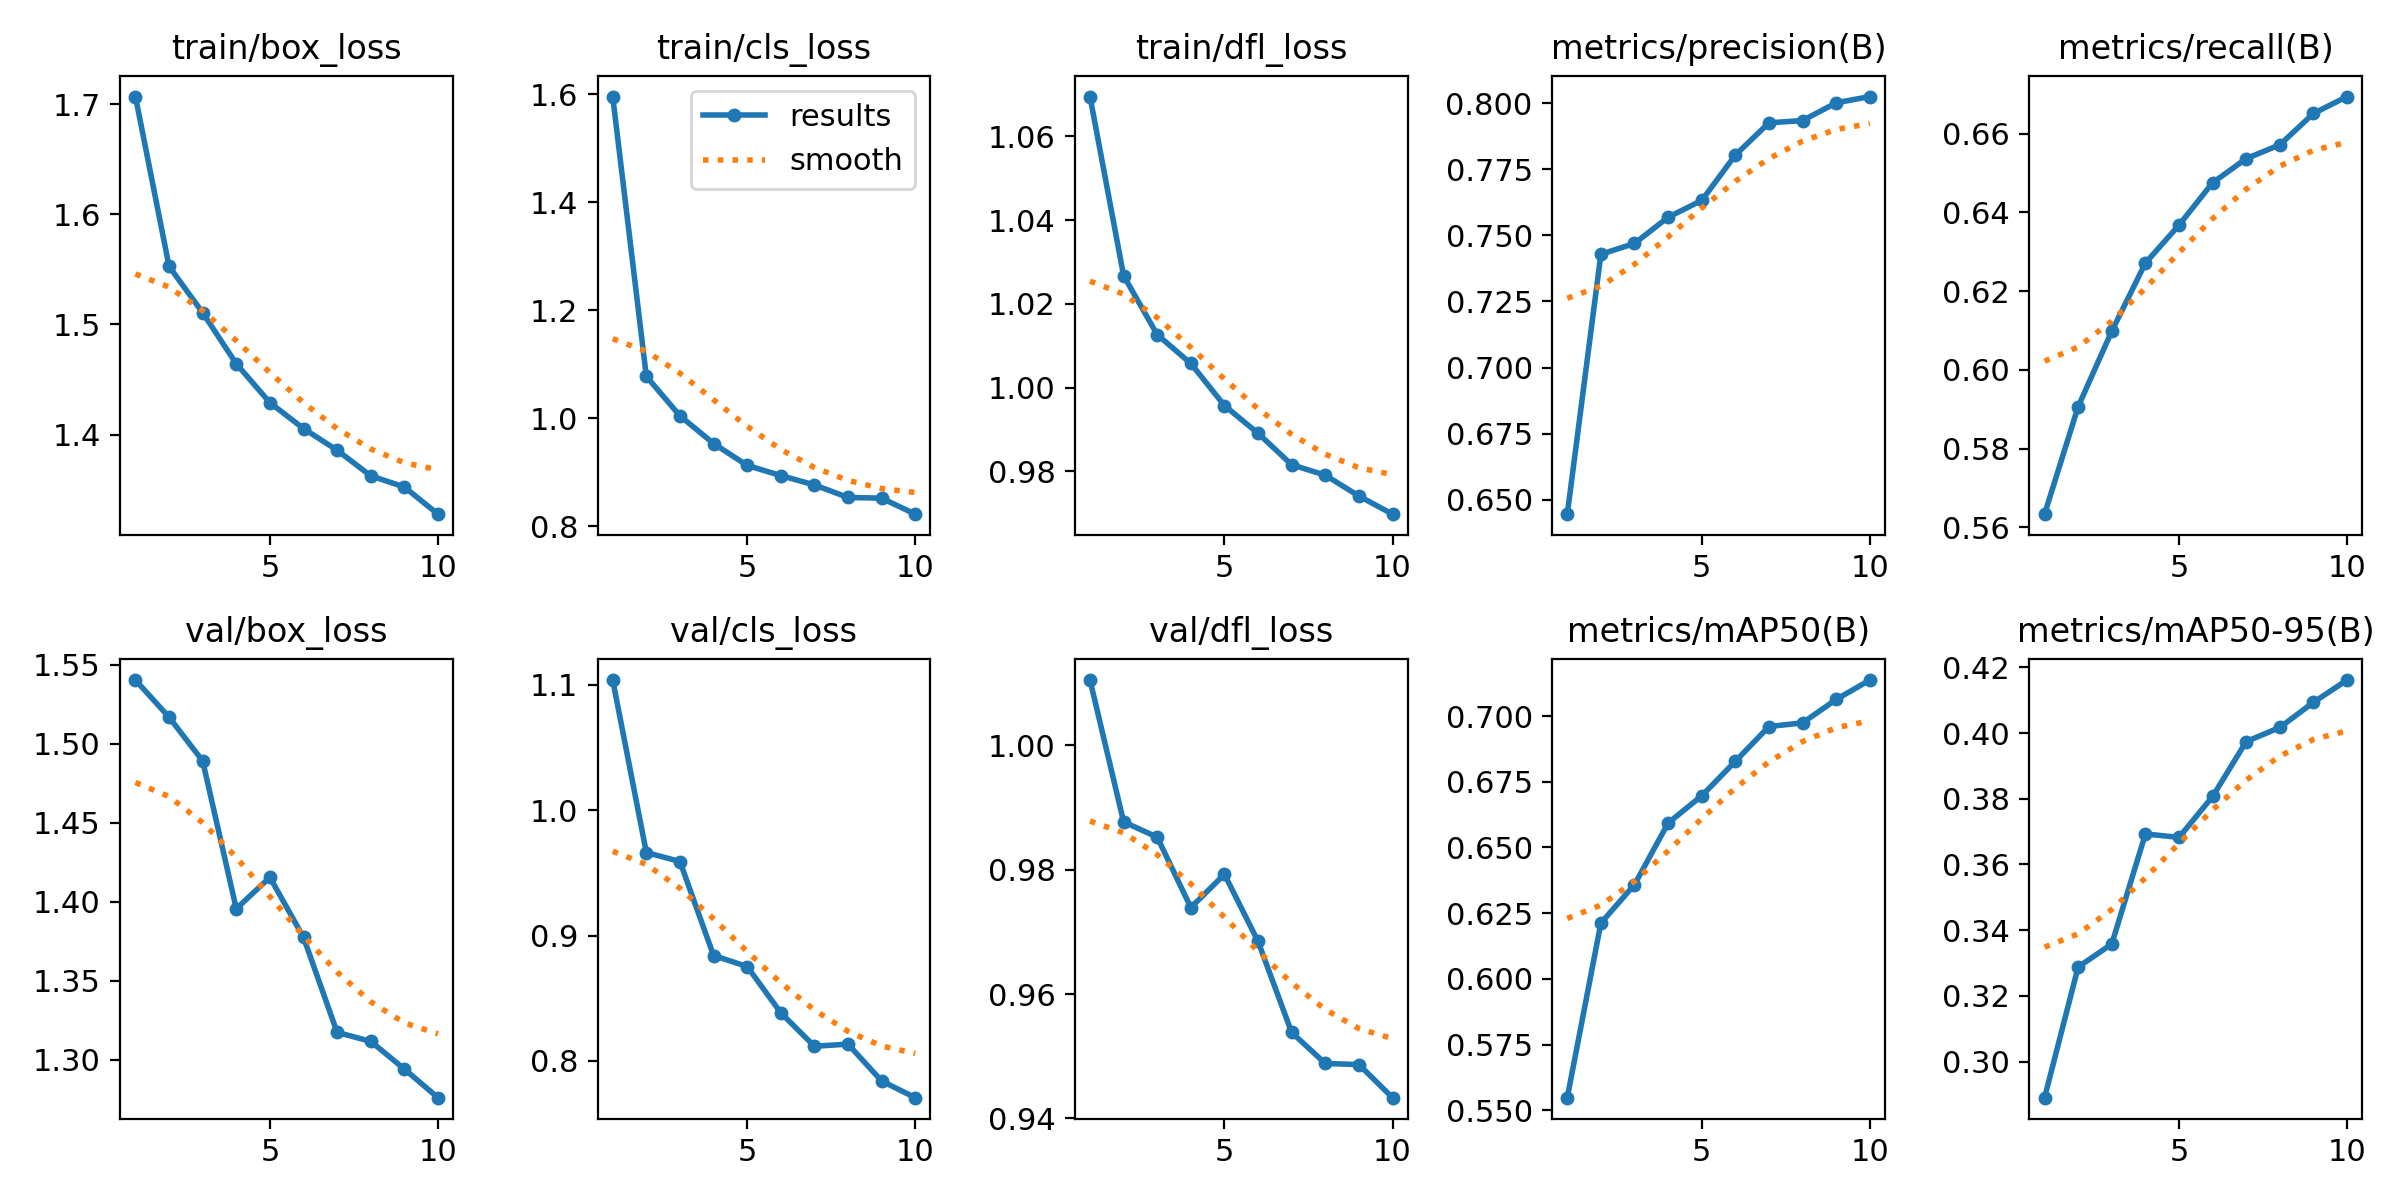

In [ ]:
from IPython.display import Image, display
import os

training_results_dir = '/content/runs/detect/train'

results_plot_path = os.path.join(training_results_dir, 'results.png')
if os.path.exists(results_plot_path):
    print("Displaying training results plot:")
    display(Image(filename=results_plot_path))
else:
    print(f"Results plot not found at {results_plot_path}. Please ensure training completed successfully and generated the plots.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
import os

model_source_path = '/content/runs/detect/train/weights/best.pt'
drive_destination_path = '/content/drive/MyDrive/yolov8_disaster_model/best.pt'

destination_dir = os.path.dirname(drive_destination_path)
if not os.path.exists(destination_dir):
    os.makedirs(destination_dir)
    print(f"Created directory: {destination_dir}")

if os.path.exists(model_source_path):
    shutil.copy(model_source_path, drive_destination_path)
    print(f"Trained model ('best.pt') successfully saved to: {drive_destination_path}")
else:
    print(f"Error: Model file not found at {model_source_path}.")

Trained model ('best.pt') successfully saved to: /content/drive/MyDrive/yolov8_disaster_model/best.pt


In [ ]:
from ultralytics import YOLO
import os

model_path_fp32 = '/content/drive/MyDrive/yolov8_disaster_model/best.pt'

if not os.path.exists(model_path_fp32):
    print(f"Error: Trained model not found at {model_path_fp32}")
    model_path_fp32 = '/content/runs/detect/train/weights/best.pt'
    if not os.path.exists(model_path_fp32):
        raise FileNotFoundError("No trained YOLOv8 model found. Please ensure it was trained and saved correctly.")
    else:
        print(f"Using locally trained model at {model_path_fp32}")

print(f"Loading original FP32 model from: {model_path_fp32}")
model_fp32 = YOLO(model_path_fp32)
print("FP32 model loaded.")

Loading original FP32 model from: /content/drive/MyDrive/yolov8_disaster_model/best.pt
FP32 model loaded.


In [ ]:
import torch
import shutil
import os

drive_quantized_path = '/content/drive/MyDrive/yolov8_disaster_model/best_int8.onnx'

print(f"Exporting FP32 model to INT8 ONNX format.")

try:
    local_exported_int8_path = model_fp32.export(format='onnx', int8=True, simplify=True, opset=13, name='best_int8_quantized_model')

    destination_dir = os.path.dirname(drive_quantized_path)
    if not os.path.exists(destination_dir):
        os.makedirs(destination_dir)
        print(f"Created directory: {destination_dir}")

    if os.path.exists(local_exported_int8_path):
        shutil.move(local_exported_int8_path, drive_quantized_path)
        print(f"INT8 quantized model successfully moved to: {drive_quantized_path}")
    else:
        print(f"Error: Exported INT8 model not found at {local_exported_int8_path}.")

except Exception as e:
    print(f"Error during INT8 quantization export: {e}")
    print("This might require specific dependency versions or a more involved PTQ setup.")
    print("Attempting export to regular ONNX (FP32) as a fallback:")
    try:
        drive_fp32_onnx_path = '/content/drive/MyDrive/yolov8_disaster_model/best_fp32.onnx'
        local_exported_fp32_path = model_fp32.export(format='onnx', simplify=True, opset=13, name='best_fp32_onnx_model_fallback')

        destination_dir = os.path.dirname(drive_fp32_onnx_path)
        if not os.path.exists(destination_dir):
            os.makedirs(destination_dir)
            print(f"Created directory: {destination_dir}")

        if os.path.exists(local_exported_fp32_path):
            shutil.move(local_exported_fp32_path, drive_fp32_onnx_path)
            print(f"FP32 ONNX model successfully moved to: {drive_fp32_onnx_path}")
        else:
            print(f"Error: Exported FP32 ONNX model not found at {local_exported_fp32_path}.")

    except Exception as fallback_e:
        print(f"Fallback ONNX export failed: {fallback_e}")

Exporting FP32 model to INT8 ONNX format.
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Error during INT8 quantization export: ERROR ❌️ argument 'int8' is not supported for format='onnx'
This might require specific dependency versions or a more involved PTQ setup.
Attempting export to regular ONNX (FP32) as a fallback:
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/yolov8_disaster_model/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 8, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment 

In [ ]:
import os
from onnxruntime.quantization import quantize_dynamic, QuantType

fp32_onnx_model_path = '/content/drive/MyDrive/yolov8_disaster_model/best_fp32.onnx'
int8_onnx_model_path = '/content/drive/MyDrive/yolov8_disaster_model/best_int8_quantized.onnx'

if not os.path.exists(fp32_onnx_model_path):
    print(f"Error: FP32 ONNX model not found at {fp32_onnx_model_path}")
    print("Please ensure the previous export step completed successfully to generate best_fp32.onnx.")
else:
    print(f"Performing dynamic quantization on: {fp32_onnx_model_path}")
    try:
        quantize_dynamic(
            model_input=fp32_onnx_model_path,
            model_output=int8_onnx_model_path,
            per_channel=False,
            reduce_range=False,
            weight_type=QuantType.QInt8
        )
        print(f"INT8 quantized ONNX model saved to: {int8_onnx_model_path}")
    except Exception as e:
        print(f"Error during ONNX dynamic quantization: {e}")
        print("Ensure you have `onnxruntime-quantization` installed if this error persists.")

Performing dynamic quantization on: /content/drive/MyDrive/yolov8_disaster_model/best_fp32.onnx
INT8 quantized ONNX model saved to: /content/drive/MyDrive/yolov8_disaster_model/best_int8_quantized.onnx


In [ ]:
import onnxruntime as ort
import time
import numpy as np
from PIL import Image
import cv2
import glob
import random
import os

fp32_onnx_model_path = '/content/drive/MyDrive/yolov8_disaster_model/best_fp32.onnx'
int8_onnx_model_path = '/content/drive/MyDrive/yolov8_disaster_model/best_int8_quantized.onnx'

if not os.path.exists(fp32_onnx_model_path):
    print(f"Error: FP32 ONNX model not found at {fp32_onnx_model_path}")
    exit()
if not os.path.exists(int8_onnx_model_path):
    print(f"Error: INT8 ONNX model not found at {int8_onnx_model_path}")
    exit()

print("Loading ONNX models...")
sess_options = ort.SessionOptions()
providers = ['CPUExecutionProvider'] # Use 'CUDAExecutionProvider' if GPU is available and set up

session_fp32 = ort.InferenceSession(fp32_onnx_model_path, sess_options, providers=providers)
session_int8 = ort.InferenceSession(int8_onnx_model_path, sess_options, providers=providers)

print("Models loaded successfully.")

input_name = session_fp32.get_inputs()[0].name
output_name_fp32 = session_fp32.get_outputs()[0].name
output_name_int8 = session_int8.get_outputs()[0].name

input_shape = session_fp32.get_inputs()[0].shape
input_height, input_width = input_shape[2], input_shape[3]

print(f"Input name: {input_name}, Input shape: {input_shape}")

Loading ONNX models...
Models loaded successfully.
Input name: images, Input shape: [1, 3, 640, 640]


In [ ]:
def preprocess_image(image_path, target_height, target_width):
    img = Image.open(image_path).convert('RGB')
    img = img.resize((target_width, target_height))
    img_np = np.array(img).astype(np.float32) / 255.0
    img_np = img_np.transpose(2, 0, 1)
    img_np = np.expand_dims(img_np, axis=0)
    return img_np

def run_inference(session, input_data):
    input_feed = {session.get_inputs()[0].name: input_data}
    outputs = session.run(None, input_feed)
    return outputs

test_images_dir = 'dataset/new_dataset3/test/images'
if not os.path.exists(test_images_dir):
    print(f"Error: Test images directory not found at {test_images_dir}")
    exit()

image_files = glob.glob(os.path.join(test_images_dir, '*.jpg')) + glob.glob(os.path.join(test_images_dir, '*.png'))

if not image_files:
    print(f"No image files found in {test_images_dir}")
    exit()

num_samples = min(20, len(image_files))
selected_images = random.sample(image_files, num_samples)

print(f"Running inference on {num_samples} sample images...")

times_fp32 = []
times_int8 = []

for img_path in selected_images:
    preprocessed_img = preprocess_image(img_path, input_height, input_width)

    start_time = time.perf_counter()
    _ = run_inference(session_fp32, preprocessed_img)
    end_time = time.perf_counter()
    times_fp32.append(end_time - start_time)

    start_time = time.perf_counter()
    _ = run_inference(session_int8, preprocessed_img)
    end_time = time.perf_counter()
    times_int8.append(end_time - start_time)

avg_time_fp32 = np.mean(times_fp32) * 1000
avg_time_int8 = np.mean(times_int8) * 1000

print("\n--- Inference Speed Comparison ---")
print(f"Average FP32 Inference Time: {avg_time_fp32:.3f} ms")
print(f"Average INT8 Inference Time: {avg_time_int8:.3f} ms")

if avg_time_fp32 > avg_time_int8:
    speed_up = avg_time_fp32 / avg_time_int8
    print(f"The INT8 model is approximately {speed_up:.2f}x faster than the FP32 model.")
elif avg_time_fp32 < avg_time_int8:
    slow_down = avg_time_int8 / avg_time_fp32
    print(f"The FP32 model is approximately {slow_down:.2f}x faster than the INT8 model (quantization resulted in slowdown). This is unexpected for dynamic quantization; check setup.")
else:
    print("Both models have similar average inference times.")

Running inference on 20 sample images...

--- Inference Speed Comparison ---
Average FP32 Inference Time: 102.053 ms
Average INT8 Inference Time: 676.474 ms
The FP32 model is approximately 6.63x faster than the INT8 model (quantization resulted in slowdown). This is unexpected for dynamic quantization; check setup.


In [ ]:
from ultralytics import YOLO
import os

fp32_onnx_model_path = '/content/drive/MyDrive/yolov8_disaster_model/best_fp32.onnx'
int8_onnx_model_path = '/content/drive/MyDrive/yolov8_disaster_model/best_int8_quantized.onnx'
data_yaml_path = 'data.yaml'

print(f"\nEvaluating FP32 ONNX model: {fp32_onnx_model_path}")
if not os.path.exists(fp32_onnx_model_path):
    print(f"Error: FP32 ONNX model not found at {fp32_onnx_model_path}")
    fp32_metrics = None
else:
    try:
        model_fp32_onnx = YOLO(fp32_onnx_model_path)
        fp32_metrics = model_fp32_onnx.val(data=data_yaml_path)
        print("FP32 ONNX Model Validation Complete.")
    except Exception as e:
        print(f"Error evaluating FP32 ONNX model: {e}")
        fp32_metrics = None

print(f"\nEvaluating INT8 Quantized ONNX model: {int8_onnx_model_path}")
if not os.path.exists(int8_onnx_model_path):
    print(f"Error: INT8 ONNX model not found at {int8_onnx_model_path}")
    int8_metrics = None
else:
    try:
        model_int8_onnx = YOLO(int8_onnx_model_path)
        int8_metrics = model_int8_onnx.val(data=data_yaml_path)
        print("INT8 Quantized ONNX Model Validation Complete.")
    except Exception as e:
        print(f"Error evaluating INT8 Quantized ONNX model: {e}")
        int8_metrics = None

print("\n--- Accuracy Comparison (mAP) ---")

if fp32_metrics:
    print(f"FP32 ONNX Model mAP50-95: {fp32_metrics.box.map:.4f}")
    print(f"FP32 ONNX Model mAP50:    {fp32_metrics.box.map50:.4f}")
else:
    print("FP32 ONNX model metrics could not be obtained.")

if int8_metrics:
    print(f"INT8 ONNX Model mAP50-95: {int8_metrics.box.map:.4f}")
    print(f"INT8 ONNX Model mAP50:    {int8_metrics.box.map50:.4f}")
else:
    print("INT8 ONNX model metrics could not be obtained.")

print("\nThis comparison shows the impact of quantization on detection accuracy.")


Evaluating FP32 ONNX model: /content/drive/MyDrive/yolov8_disaster_model/best_fp32.onnx
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
Loading /content/drive/MyDrive/yolov8_disaster_model/best_fp32.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CPUExecutionProvider
Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3695.5±1578.2 MB/s, size: 151.3 KB)
val: Scanning /content/dataset/new_dataset3/val/labels... 2043 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2043/2043 1.1Kit/s 1.9s
val: New cache created: /content/dataset/new_dataset3/val/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2043/2043 7.5it/s 4:33
                   all       2043     

/tmp/ipykernel_7295/2639054147.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Average Inference Time (ms)', data=speed_df, palette='viridis')


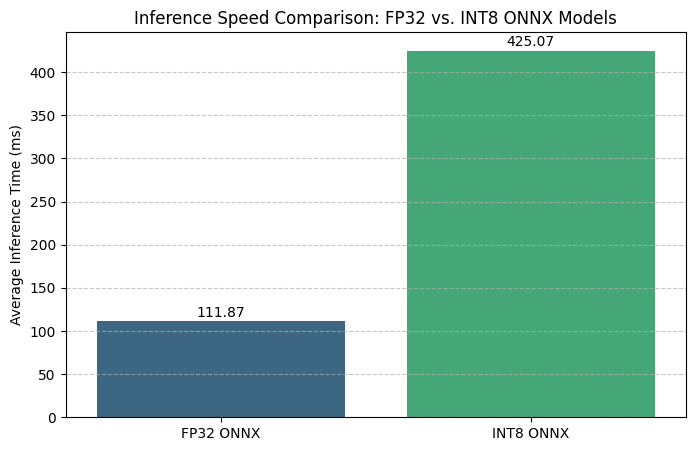

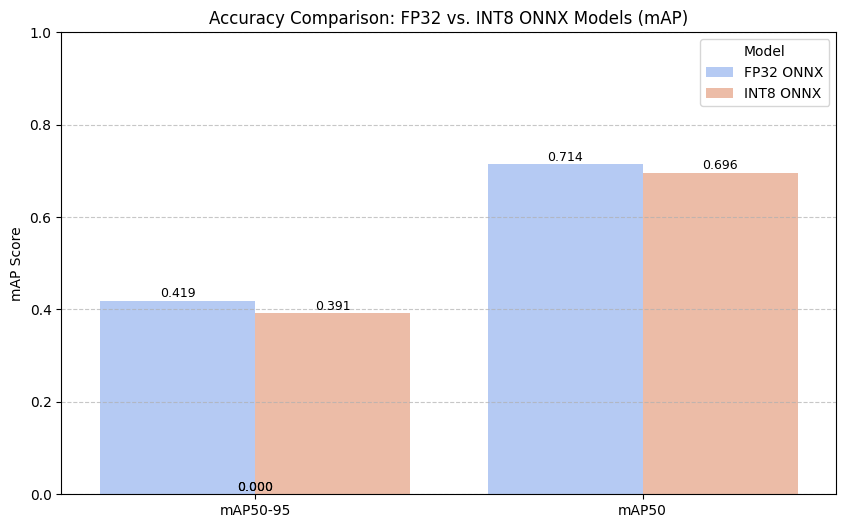

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

speed_data = {
    'Model': ['FP32 ONNX', 'INT8 ONNX'],
    'Average Inference Time (ms)': [avg_time_fp32, avg_time_int8]
}
speed_df = pd.DataFrame(speed_data)

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Average Inference Time (ms)', data=speed_df, palette='viridis')
plt.title('Inference Speed Comparison: FP32 vs. INT8 ONNX Models')
plt.ylabel('Average Inference Time (ms)')
plt.xlabel('')
for index, row in speed_df.iterrows():
    plt.text(row.name, row['Average Inference Time (ms)'] + 5, f"{row['Average Inference Time (ms)']:.2f}", color='black', ha="center")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

if fp32_metrics and int8_metrics:
    accuracy_data = {
        'Metric': ['mAP50-95', 'mAP50', 'mAP50-95', 'mAP50'],
        'Model': ['FP32 ONNX', 'FP32 ONNX', 'INT8 ONNX', 'INT8 ONNX'],
        'Score': [
            fp32_metrics.box.map,
            fp32_metrics.box.map50,
            int8_metrics.box.map,
            int8_metrics.box.map50
        ]
    }
    accuracy_df = pd.DataFrame(accuracy_data)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Metric', y='Score', hue='Model', data=accuracy_df, palette='coolwarm')
    plt.title('Accuracy Comparison: FP32 vs. INT8 ONNX Models (mAP)')
    plt.ylabel('mAP Score')
    plt.xlabel('')
    plt.ylim(0, 1)
    for i, p in enumerate(plt.gca().patches):
        plt.gca().annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                           textcoords='offset points')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Model')
    plt.show()
else:
    print("Cannot generate accuracy plots because metrics for one or both models are missing.")

Detected input width from ONNX model: 640
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
FP32 ONNX model loaded successfully.
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
INT8 ONNX model loaded successfully.

Processing image: collapsed_building_image0094_4.png

Running FP32 ONNX model prediction...
Loading /content/drive/MyDrive/yolov8_disaster_model/best_fp32.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CUDAExecutionProvider

image 1/1 /content/dataset/new_dataset3/test/images/collapsed_building_image0094_4.png: 640x640 37 collapsed_buildings, 8.9ms
Speed: 5.8ms preprocess, 8.9ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/compare_models/fp32_output
FP

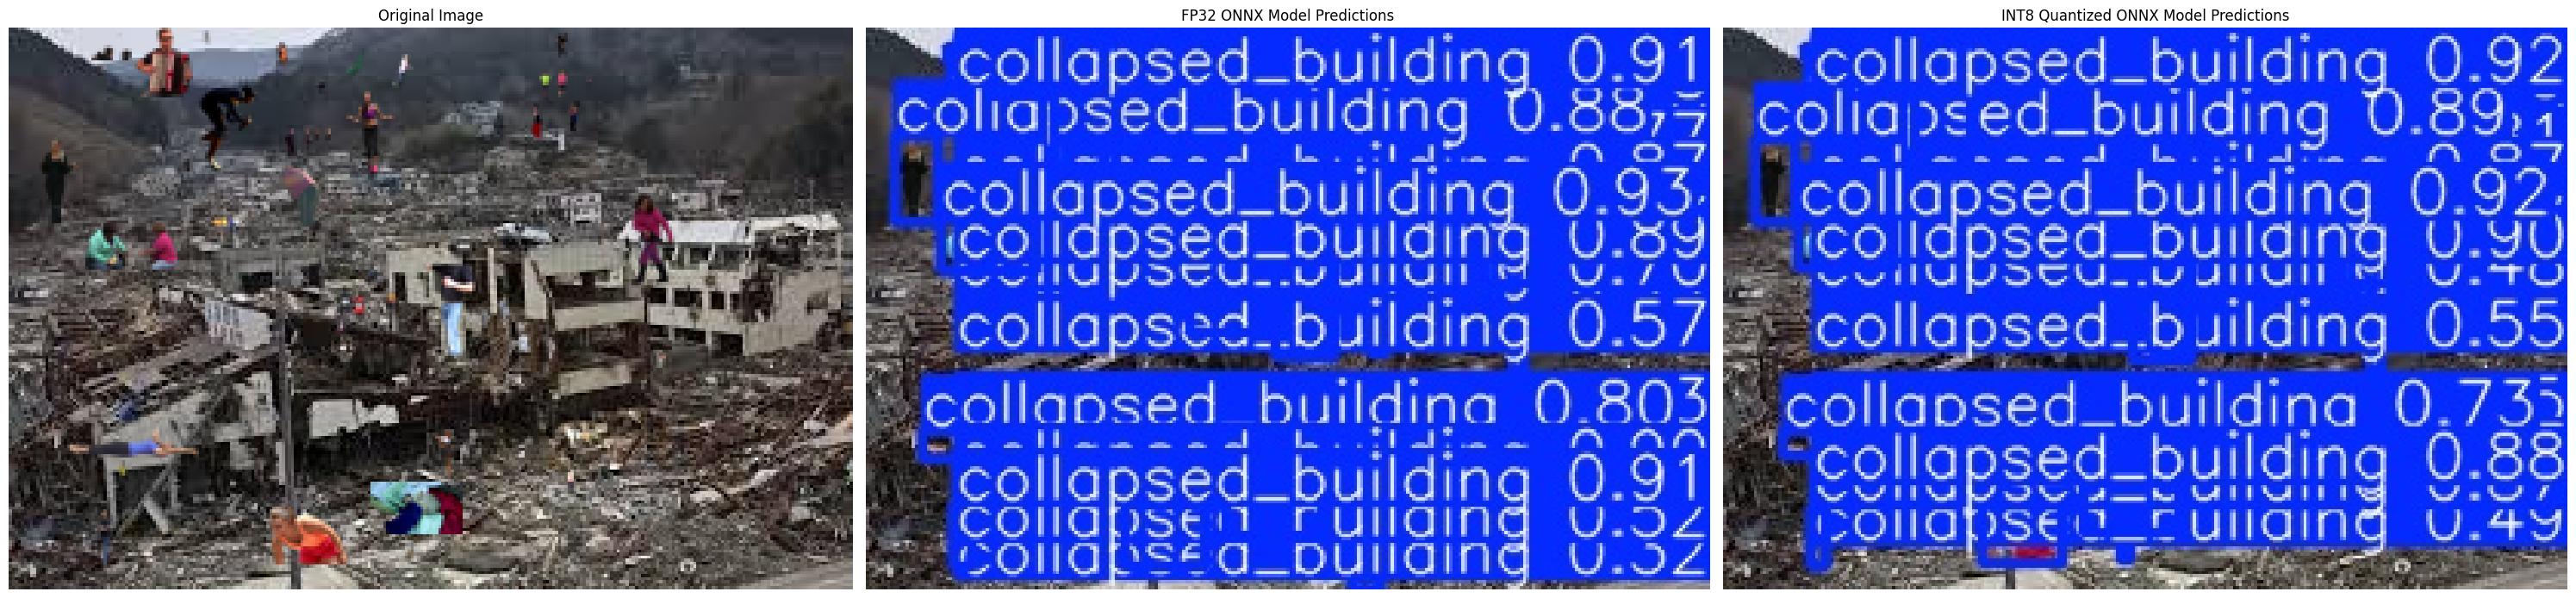


--- Detected Object Counts ---
FP32 ONNX Model Detections:
  collapsed_building: 37
INT8 Quantized ONNX Model Detections:
  collapsed_building: 35


In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
from ultralytics import YOLO
import onnxruntime as ort
from IPython.display import display, Image as IPythonImage
import io
import numpy as np

fp32_onnx_model_path = '/content/drive/MyDrive/yolov8_disaster_model/best_fp32.onnx'
int8_onnx_model_path = '/content/drive/MyDrive/yolov8_disaster_model/best_int8_quantized.onnx'

sess_options = ort.SessionOptions()
providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']

input_width = 640
try:
    session_fp32_temp = ort.InferenceSession(fp32_onnx_model_path, sess_options, providers=providers)
    input_shape_temp = session_fp32_temp.get_inputs()[0].shape
    input_height_detected, input_width_detected = input_shape_temp[2], input_shape_temp[3]
    if input_width_detected and input_height_detected:
        input_width = input_width_detected
        print(f"Detected input width from ONNX model: {input_width}")
except Exception as e:
    print(f"Could not determine input width from ONNX model ({e}). Using default: {input_width}.")

try:
    model_fp32_onnx = YOLO(fp32_onnx_model_path)
    print("FP32 ONNX model loaded successfully.")
except Exception as e:
    print(f"Error loading FP32 ONNX model: {e}")
    model_fp32_onnx = None

try:
    model_int8_onnx = YOLO(int8_onnx_model_path)
    print("INT8 ONNX model loaded successfully.")
except Exception as e:
    print(f"Error loading INT8 ONNX model: {e}")
    model_int8_onnx = None

def find_annotated_image_robust(search_dir, original_image_name):
    if not os.path.exists(search_dir):
        return None

    base_name_without_ext = os.path.splitext(original_image_name)[0]

    candidate_files = []
    for f_name in os.listdir(search_dir):
        if f_name.lower().endswith(('.jpg', '.png')) and f_name.startswith(base_name_without_ext):
            candidate_files.append(os.path.join(search_dir, f_name))

    if not candidate_files:
        all_image_files = [os.path.join(search_dir, f) for f in os.listdir(search_dir) if f.lower().endswith(('.jpg', '.png'))]
        if all_image_files:
            all_image_files.sort(key=os.path.getmtime, reverse=True)
            return all_image_files[0]
        return None

    candidate_files.sort(key=os.path.getmtime, reverse=True)
    return candidate_files[0]

test_images_dir = 'dataset/new_dataset3/test/images'

if not os.path.exists(test_images_dir):
    print(f"Error: Test images directory not found at {test_images_dir}")
elif not model_fp32_onnx or not model_int8_onnx:
    print("Cannot proceed with comparison as one or both models failed to load.")
else:
    import os
    image_files = [f for f in os.listdir(test_images_dir) if f.lower().endswith(('.jpg', '.png'))]
    if not image_files:
        print(f"No image files found in {test_images_dir}")
    else:
        sample_image_name = random.choice(image_files)
        sample_image_path = os.path.join(test_images_dir, sample_image_name)

        raw_img = Image.open(sample_image_path)

        print(f"\nProcessing image: {sample_image_name}")

        fp32_predict_project = 'compare_models'
        fp32_predict_name = 'fp32_output'
        print("\nRunning FP32 ONNX model prediction...")
        fp32_results = model_fp32_onnx.predict(
            source=sample_image_path,
            save=True,
            project=fp32_predict_project,
            name=fp32_predict_name,
            exist_ok=True,
            imgsz=input_width,
            conf=0.25
        )
        fp32_save_dir = fp32_results[0].save_dir
        fp32_annotated_path = find_annotated_image_robust(fp32_save_dir, sample_image_name)
        print(f"FP32 Annotated image path: {fp32_annotated_path}")

        int8_predict_project = 'compare_models'
        int8_predict_name = 'int8_output'
        print("\nRunning INT8 Quantized ONNX model prediction...")
        int8_results = model_int8_onnx.predict(
            source=sample_image_path,
            save=True,
            project=int8_predict_project,
            name=int8_predict_name,
            exist_ok=True,
            imgsz=input_width,
            conf=0.25
        )
        int8_save_dir = int8_results[0].save_dir
        int8_annotated_path = find_annotated_image_robust(int8_save_dir, sample_image_name)
        print(f"INT8 Annotated image path: {int8_annotated_path}")

        if fp32_annotated_path and os.path.exists(fp32_annotated_path) and \
           int8_annotated_path and os.path.exists(int8_annotated_path):

            fp32_annotated_img = Image.open(fp32_annotated_path)
            int8_annotated_img = Image.open(int8_annotated_path)

            fig, axes = plt.subplots(1, 3, figsize=(30, 12))

            axes[0].imshow(raw_img)
            axes[0].set_title('Original Image')
            axes[0].axis('off')

            axes[1].imshow(fp32_annotated_img)
            axes[1].set_title('FP32 ONNX Model Predictions')
            axes[1].axis('off')

            axes[2].imshow(int8_annotated_img)
            axes[2].set_title('INT8 Quantized ONNX Model Predictions')
            axes[2].axis('off')

            plt.tight_layout()

            buf = io.BytesIO()
            plt.savefig(buf, format='png', bbox_inches='tight')
            buf.seek(0)
            display(IPythonImage(data=buf.read()))
            plt.close(fig)

            class_names = model_fp32_onnx.names

            fp32_counts = {}
            if fp32_results and len(fp32_results) > 0 and fp32_results[0].boxes:
                for cls_id in fp32_results[0].boxes.cls.cpu().numpy():
                    class_name = class_names[int(cls_id)]
                    fp32_counts[class_name] = fp32_counts.get(class_name, 0) + 1

            int8_counts = {}
            if int8_results and len(int8_results) > 0 and int8_results[0].boxes:
                for cls_id in int8_results[0].boxes.cls.cpu().numpy():
                    class_name = class_names[int(cls_id)]
                    int8_counts[class_name] = int8_counts.get(class_name, 0) + 1

            print("\n--- Detected Object Counts ---")
            print("FP32 ONNX Model Detections:")
            if fp32_counts:
                for class_name, count in fp32_counts.items():
                    print(f"  {class_name}: {count}")
            else:
                print("  No objects detected by FP32 model.")

            print("INT8 Quantized ONNX Model Detections:")
            if int8_counts:
                for class_name, count in int8_counts.items():
                    print(f"  {class_name}: {count}")
            else:
                print("  No objects detected by INT8 model.")

        else:
            print("Failed to find one or both annotated images. Check paths and YOLO output.")
            print(f"FP32 Annotated Path: {fp32_annotated_path}, Exists: {os.path.exists(fp32_annotated_path) if fp32_annotated_path else False}")
            print(f"INT8 Annotated Path: {int8_annotated_path}, Exists: {os.path.exists(int8_annotated_path) if int8_annotated_path else False}")